<a href="https://colab.research.google.com/github/FatimaZulfiqar02/intro-ml-course-winter2025/blob/main/Datathon_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datathon 1
## Dataset #1: Lung Cancer Risk Factors from Tikur Ambesa Hospital


## Data Exploration

Upload the file from your local drive.

In [ ]:
## Load data
# Import libraries and upload the file
import pandas as pd
from google.colab import files
import io
uploaded = files.upload()

# Read the data as a dataframe
lung_data = pd.read_csv

Saving Datathon_1_Dataset_1.csv to Datathon_1_Dataset_1.csv


Explore the data and assess alignment with the data dictionary.

In [ ]:
## Explore the data
# First 5 rows of data consistent with data dictionary (DD)
print(lung_data.head())

# Size of data consistent with DD
print(lung_data.shape)

# Display summary statistics for data
# Min and max values consistent with DD
print(lung_data.describe())

# No missing or null values
print(lung_data.isna().sum())

   id  age  sex  air_pm25  alcohol  genetic_risk  history_lungcnd  bmi  \
0   1   33    1        14        4             4                2   22   
1   2   17    1        19        1             4                2   19   
2   3   35    1        34        5             7                3   27   
3   4   37    1        65        7             9                5   27   
4   5   46    1        46        8             8                4   25   

   smoke_packyrs  smoke_passive  history_chestpain  history_hemoptysis  \
0             11              0                  0                   2   
1              2              1                  0                   1   
2              7              0                  1                   4   
3             33              2                  3                   4   
4             29              2                  3                   4   

   severity  
0         0  
1         1  
2         2  
3         2  
4         2  
(1465, 13)
               

Visualize and investigate the severity variable.

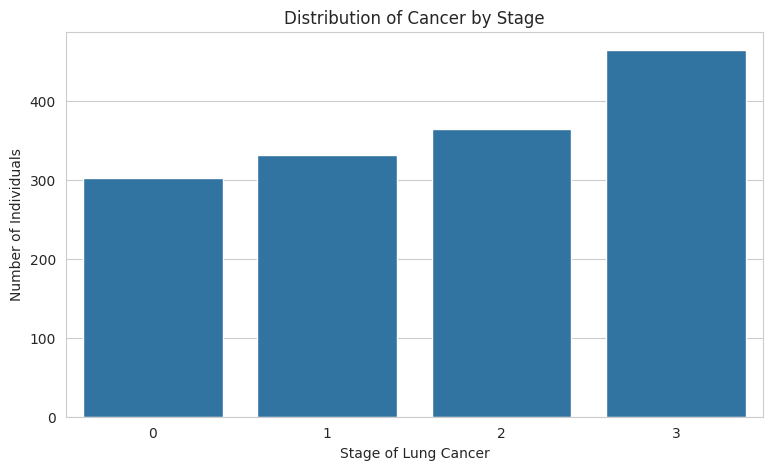

   severity   id  age  sex  air_pm25  alcohol  genetic_risk  history_lungcnd  \
0         0  303  303  303       303      303           303              303   
1         1  332  332  332       332      332           332              332   
2         2  365  365  365       365      365           365              365   
3         3  465  465  465       465      465           465              465   

   bmi  smoke_packyrs  smoke_passive  history_chestpain  history_hemoptysis  
0  303            303            303                303                 303  
1  332            332            332                332                 332  
2  365            365            365                365                 365  
3  465            465            465                465                 465  


In [ ]:
## Visualize the data
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a countplot for 'severity'
# Distribution consistent with DD and dataset information
sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
sns.countplot(x = lung_data['severity'])
plt.title('Distribution of Cancer by Stage')
plt.xlabel('Stage of Lung Cancer')
plt.ylabel('Number of Individuals')
plt.show()

# Check raw count by 'severity'
# Counts consistent with DD and dataset information
count_by_stage = lung_data.groupby('severity').count().reset_index()
print(count_by_stage)

# Distribution of patients (primarily stage 1-3) suggests a potential for class
# imbalance if the presence of cancer will be treated as a binary variable in
# the model

Visualize and investigate sex.

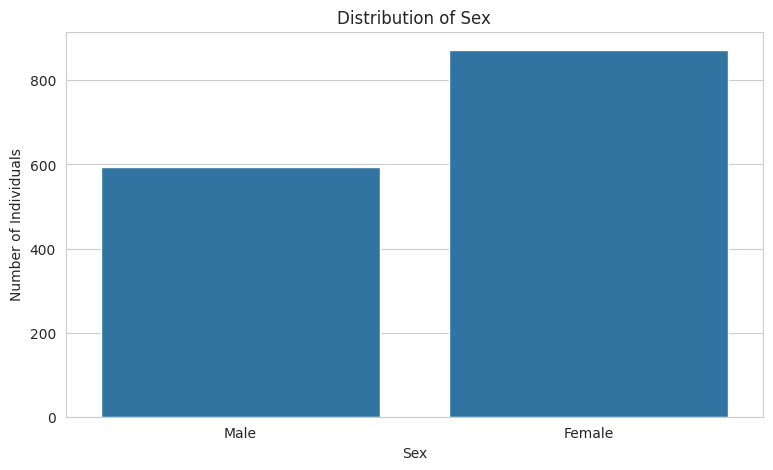

   sex   id  age  air_pm25  alcohol  genetic_risk  history_lungcnd  bmi  \
0    0  593  593       593      593           593              593  593   
1    1  872  872       872      872           872              872  872   

   smoke_packyrs  smoke_passive  history_chestpain  history_hemoptysis  \
0            593            593                593                 593   
1            872            872                872                 872   

   severity  
0       593  
1       872  


In [ ]:
# Create a countplot for 'sex'
# Distribution consistent with DD and dataset information
sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
sns.countplot(x = lung_data['sex'])
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Individuals')
plt.xticks([0, 1], ['Male', 'Female'])
plt.show()

# Check raw count by 'sex'
# Counts consistent with DD and dataset information
count_by_sex = lung_data.groupby('sex').count().reset_index()
print(count_by_sex)

Visualize and investigate severity by sex.

In [ ]:
# Create interactive plots
# Import libraries
import plotly.express as px
import plotly.io as pio
pio.renderers.default='notebook'

# Transform the 'sex' column into readable strings
lung_data_str = lung_data.assign(
    sex=lung_data['sex'].replace({0: 'Male', 1: 'Female'}))

# Create a countplot for 'severity' by 'sex'
# There is an apparent trend between female sex and increased disease severity,
# which is aligned with the literature
lung_sev = px.histogram(lung_data_str, x='severity',
                        labels={"severity": "Stage of Lung Cancer"},
                        title='Distribution of Severity by Sex',
                        color='sex', barmode='group')
lung_sev.update_layout(template="plotly_white",
                       yaxis_title="Number of Individuals",
                       legend_title_text="Sex",
                       title_x=0.5)
lung_sev.show('colab')

Visualize and investigate spread of all continuous variables.

In [ ]:
# Create a boxplot for all continuous variables
# Data consistent with DD; scaling is an issue for variables such as age and
# ambient air pollution
lung_all = px.box(lung_data, y=['age', 'air_pm25', 'alcohol', 'genetic_risk',
                                'history_lungcnd', 'bmi', 'smoke_packyrs',
                                'smoke_passive', 'history_chestpain',
                                'history_hemoptysis'],
                  title='Box Plot for All Continuous Variables')
lung_all.update_layout(template="plotly_white",
                       yaxis_title='Value',
                       xaxis_title='Variable',
                       title_x=0.5)
lung_all.show('colab')

## K-Nearest Neighbors (K-NN)

Prepare the data prior to fitting the model.

In [ ]:
## Prepare data
# Import libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create a new label called 'cancer' based on 'severity'
lung_data['cancer'] = np.where(lung_data['severity'] > 0, 1, 0) # Lung Cancer: 1, Healthy: 0

# Split data into features and label
X = lung_data[['age', 'sex', 'air_pm25', 'alcohol', 'genetic_risk',
               'history_lungcnd', 'bmi', 'smoke_packyrs', 'smoke_passive',
               'history_chestpain', 'history_hemoptysis']]
y = lung_data['cancer']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Fit and test the model.

In [ ]:
# Initialize the K-NN classifier and fit the model
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train, y_train)

# Apply the model to the test data
y_pred = knn.predict(X_test)

# Evaluate the model prediction
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 57   0]
 [  6 230]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        57
           1       1.00      0.97      0.99       236

    accuracy                           0.98       293
   macro avg       0.95      0.99      0.97       293
weighted avg       0.98      0.98      0.98       293



Test different values of $K$.

In [ ]:
# Create loop to test different values of K
for k in range(2, 11):
  print(f'K = {k}')
  knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))

K = 2
[[ 57   0]
 [  8 228]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        57
           1       1.00      0.97      0.98       236

    accuracy                           0.97       293
   macro avg       0.94      0.98      0.96       293
weighted avg       0.98      0.97      0.97       293

K = 3
[[ 57   0]
 [  7 229]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        57
           1       1.00      0.97      0.98       236

    accuracy                           0.98       293
   macro avg       0.95      0.99      0.96       293
weighted avg       0.98      0.98      0.98       293

K = 4
[[ 57   0]
 [  7 229]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        57
           1       1.00      0.97      0.98       236

    accuracy                           0.98       293
   macro avg       0.95      0.99      0.

Plot a Confusion Matrix Heatmap using $K = 5$.

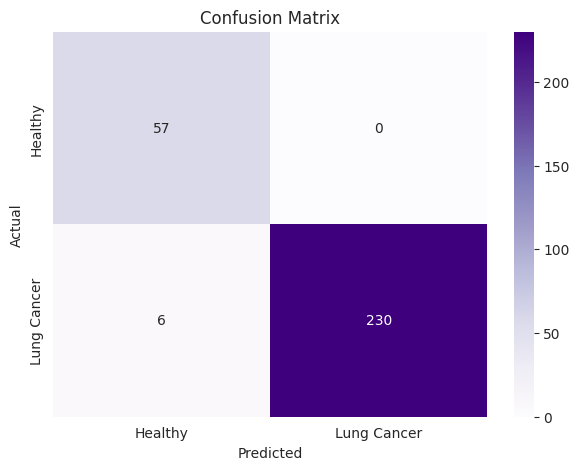

In [ ]:
# Run the model using k = 5
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Plot the confusion matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred, labels = [0, 1]),cmap='Purples', annot=True, fmt='g',
            xticklabels = ['Healthy', 'Lung Cancer'], yticklabels = ['Healthy', 'Lung Cancer']) # Healthy: 0, Lung Cancer: 1
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()